# Week 5 Lab — SOLUTIONS — ARMA Modelling of UK House-Price Growth

**MANG2074 Financial Econometrics 1**

**Objectives**

- Test for stationarity with the ADF test and interpret it correctly.
- Read ACF/PACF correlograms and the Ljung–Box statistic.
- Estimate AR, MA and ARMA models by maximum likelihood and select among them with AIC/BIC.
- Check residual whiteness and the stationarity/invertibility of the fitted model.

**Data**

`../data/ukhp.csv` — monthly UK average house price (Nationwide), 1991–2018. We model `dhp`, the monthly % change.


## Setup

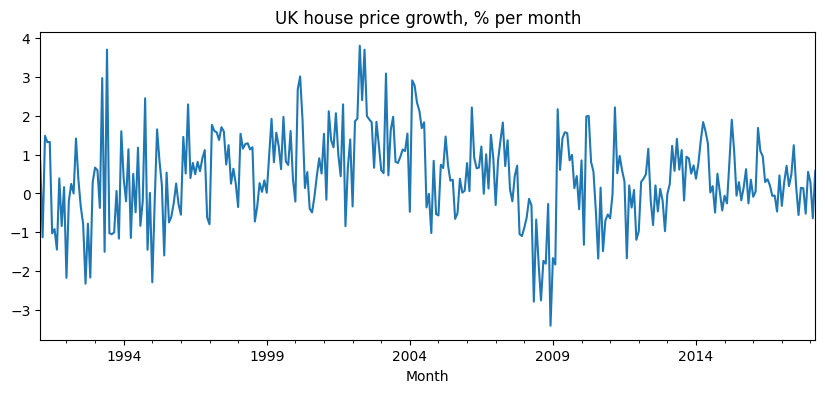

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

hp = pd.read_csv('../data/ukhp.csv', index_col=0, parse_dates=True)
hp = hp.asfreq('MS')                     # tell statsmodels it's monthly data
hp['dhp'] = 100 * hp['Average House Price'].pct_change()
dhp = hp['dhp'].dropna()
dhp.plot(figsize=(10, 4), title='UK house price growth, % per month')
plt.show()

**What to interpret.** Growth fluctuates around ~0.5% per month but with long swings: sustained booms (late 1990s–2004, ~1–2% per month) and a sustained bust (2008–09, persistently negative). Those long swings are visual evidence of autocorrelation — this series should be forecastable, unlike stock returns.

## Task 1 — Stationarity: ADF tests

In [2]:
def adf_report(x, label):
    stat, pval, usedlag, nobs, crit, icbest = adfuller(x.dropna())
    print(f"--- ADF test: {label} ---")
    print(f"test statistic = {stat:.3f}")
    print(f"p-value        = {pval:.4f}")
    print(f"critical values: 1% {crit['1%']:.3f}, 5% {crit['5%']:.3f}, 10% {crit['10%']:.3f}")
    print()

adf_report(hp['Average House Price'], 'house price LEVEL')
adf_report(dhp, 'house price GROWTH (dhp)')


--- ADF test: house price LEVEL ---
test statistic = -0.200
p-value        = 0.9385
critical values: 1% -3.452, 5% -2.871, 10% -2.572

--- ADF test: house price GROWTH (dhp) ---
test statistic = -3.272
p-value        = 0.0162
critical values: 1% -3.452, 5% -2.871, 10% -2.572



**What to interpret.** $H_0$: unit root (non-stationary). **Level:** statistic ≈ −0.20, far above (less negative than) the 5% critical value ≈ −2.87, p ≈ 0.94 — we cannot reject the unit root; the level is non-stationary, as the trending plot suggested. **Growth:** statistic ≈ −3.27 < −2.87, p ≈ 0.016 — reject the unit root at 5%; `dhp` is stationary and safe to ARMA-model. Note the direction: *rejecting* the ADF null is the good outcome for modelling.

## Task 2 — The correlogram

        acf    pacf  Ljung-Box Q  p-value
lag                                      
1    0.3575  0.3586      42.0565      0.0
2    0.4181  0.3352      99.7500      0.0
3    0.2311  0.0165     117.4358      0.0
4    0.1824 -0.0193     128.4846      0.0
5    0.1264  0.0059     133.8030      0.0
6    0.1306  0.0555     139.5021      0.0
7    0.0608 -0.0304     140.7407      0.0
8    0.0964  0.0365     143.8675      0.0
9    0.1605  0.1490     152.5558      0.0
10   0.1366  0.0405     158.8704      0.0
11   0.2545  0.1537     180.8621      0.0
12   0.2994  0.1874     211.3778      0.0

approx 95% band: +/- 0.109


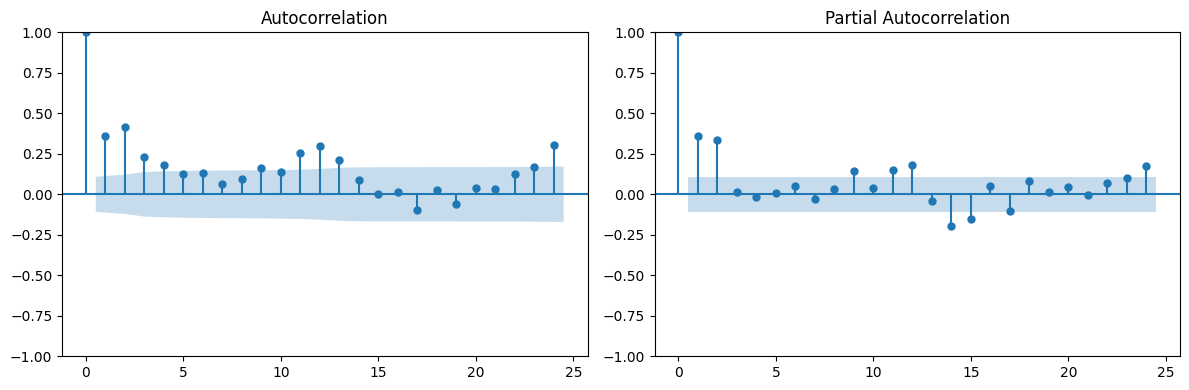

In [3]:
acf_vals, qstat, pvals = acf(dhp, nlags=12, qstat=True)
pacf_vals = pacf(dhp, nlags=12)

correlogram = pd.DataFrame({'lag': range(1, 13),
                            'acf': acf_vals[1:],
                            'pacf': pacf_vals[1:],
                            'Ljung-Box Q': qstat,
                            'p-value': pvals}).set_index('lag')
print(correlogram.round(4))
print(f"\napprox 95% band: +/- {1.96/np.sqrt(len(dhp)):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(dhp, lags=24, ax=axes[0])
plot_pacf(dhp, lags=24, ax=axes[1])
plt.tight_layout(); plt.show()


**What to interpret.** The ACF starts around 0.36–0.42 and decays slowly and irregularly over many lags; the PACF has two large spikes (lags 1–2, ≈0.36 and ≈0.34) and is essentially zero afterwards. Decaying ACF + PACF cutting off at 2 is the **AR(2) signature**. Every Ljung–Box p-value is microscopic: the autocorrelation is overwhelming — house-price growth is nothing like white noise.

## Task 3 — Estimate candidate models

In [4]:
orders = [(1,0,0), (2,0,0), (0,0,1), (1,0,1), (2,0,2)]
rows = {}
fits = {}
for o in orders:
    res = ARIMA(dhp, order=o).fit()
    name = f"ARMA({o[0]},{o[2]})"
    fits[name] = res
    rows[name] = {'AIC': res.aic, 'BIC': res.bic, 'loglik': res.llf}

ic = pd.DataFrame(rows).T
print(ic.round(2))
print()
print(fits['ARMA(1,1)'].summary())


              AIC     BIC  loglik
ARMA(1,0)  958.79  970.15 -476.40
ARMA(2,0)  922.46  937.61 -457.23
ARMA(0,1)  977.40  988.76 -485.70
ARMA(1,1)  933.42  948.57 -462.71
ARMA(2,2)  926.24  948.96 -457.12

                               SARIMAX Results                                
Dep. Variable:                    dhp   No. Observations:                  326
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -462.710
Date:                Thu, 11 Jun 2026   AIC                            933.420
Time:                        01:37:06   BIC                            948.567
Sample:                    02-01-1991   HQIC                           939.465
                         - 03-01-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const

**What to interpret.** In the ARMA(1,1) summary, the AR coefficient (~0.82) and MA coefficient (~−0.54) are both significant, and the constant ≈ 0.43 is the *unconditional mean* of monthly growth (statsmodels parameterises the intercept as the mean). The information-criterion table shows **AR(2) attains the lowest AIC *and* the lowest BIC** among these five candidates — exactly the model the correlogram suggested. ARMA(2,2) is second on AIC but its two extra parameters buy almost no log-likelihood.

## Task 4 — Which model wins?

**Answer.** Among these five candidates both criteria agree: AR(2). They need not: AIC ($-2\ln\hat L + 2k$) charges 2 per parameter while BIC ($-2\ln\hat L + k\ln T$) charges $\ln T \approx 5.8$ here, so BIC systematically favours smaller models and the two disagree whenever extra parameters buy a modest likelihood gain. Indeed, next week's full grid search over $p,q \le 5$ shows AIC's global choice is a richer ARMA(4,2) while BIC sticks with AR(2). For forecasting, parsimony usually pays (extra parameters add estimation noise that compounds over multi-step horizons) and BIC is consistent for the true order — so AR(2) is our baseline.

## Task 5 — Residual diagnostics

                               SARIMAX Results                                
Dep. Variable:                    dhp   No. Observations:                  326
Model:                 ARIMA(2, 0, 0)   Log Likelihood                -457.230
Date:                Thu, 11 Jun 2026   AIC                            922.460
Time:                        01:37:06   BIC                            937.608
Sample:                    02-01-1991   HQIC                           928.505
                         - 03-01-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4275      0.128      3.339      0.001       0.177       0.679
ar.L1          0.2361      0.044      5.331      0.000       0.149       0.323
ar.L2          0.3340      0.043      7.851      0.0

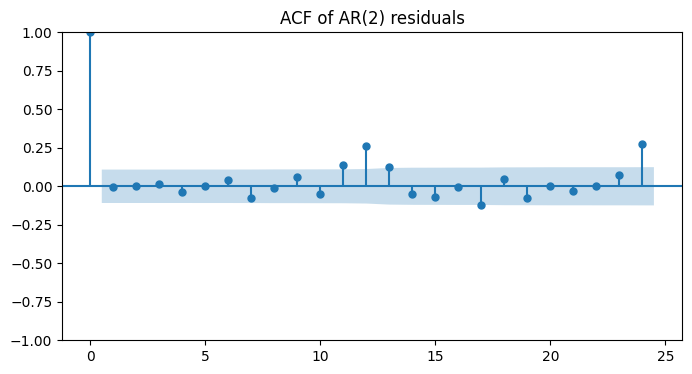

      lb_stat  lb_pvalue
6    0.993361   0.910801
12  34.385318   0.000159


In [5]:
best = ARIMA(dhp, order=(2,0,0)).fit()
print(best.summary())

fig, ax = plt.subplots(figsize=(8, 4))
plot_acf(best.resid, lags=24, ax=ax, title='ACF of AR(2) residuals')
plt.show()

lb = sm.stats.acorr_ljungbox(best.resid, lags=[6, 12], model_df=2)
print(lb)


**What to interpret.** Both AR coefficients are positive and highly significant ($\hat\phi_1 \approx 0.24$, $\hat\phi_2 \approx 0.33$). The Ljung–Box test (with `model_df=2` to deduct the two estimated AR parameters) is comfortably clean at 6 lags (p ≈ 0.91): the short-run dynamics are fully captured. At 12 lags, however, it **rejects** (p ≈ 0.0002) — look at the residual ACF and you will see the culprit: a spike around lag 12. That is **seasonality** (monthly housing data has a strong annual pattern), exactly the pitfall flagged in the lecture. The AR(2) is adequate for the non-seasonal dynamics we are studying; a fully polished model would add seasonal dummies or a seasonal AR term (SARMA). Box–Jenkins step 3 has done its job: it told us precisely what is still missing.

## Task 6 — Stationarity and invertibility of the fitted model

In [6]:
proc = sm.tsa.ArmaProcess.from_estimation(best)
print(f"stationary?  {proc.isstationary}")
print(f"invertible?  {proc.isinvertible}")
print(f"AR roots: {proc.arroots}")
print(f"modulus : {np.abs(proc.arroots)}")

dominant = 1 / np.abs(proc.arroots).min()
halflife = np.log(0.5) / np.log(dominant)
print(f"\ndominant root persistence per month = {dominant:.3f}")
print(f"implied shock half-life = {halflife:.1f} months")


stationary?  True
invertible?  True
AR roots: [-2.11940291  1.41254012]
modulus : [2.11940291 1.41254012]

dominant root persistence per month = 0.708
implied shock half-life = 2.0 months


**What to interpret.** Both AR roots lie outside the unit circle (modulus > 1), so the fitted AR(2) is stationary (invertibility is automatic with no MA part). The dominant root implies persistence of roughly 0.7–0.8 per month — a shock to house-price growth takes around 2–3 months to halve, and the long ACF tail shows echoes lasting a year or more.

## Task 7 — Economic interpretation

UK house-price growth is strongly *positively autocorrelated*: a hot month tends to be followed by more hot months. This momentum is economically intuitive — housing transactions are slow, information diffuses gradually, the index itself is partly smoothed, and credit conditions move in long cycles. The contrast with equity returns is stark: liquid stock markets arbitrage away predictability within days (weak-form efficiency), so their ACFs are flat, while housing has no army of arbitrageurs who can short Southampton semis. The practical payoff: an atheoretical AR(2) genuinely forecasts house-price growth at short horizons — which is exactly what we exploit next week.